In [39]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import numpy as np
import pandas as pd
import janitor

from torch.utils.data import DataLoader
from datasets import DatasetDict, Dataset

import warnings
warnings.filterwarnings('ignore', message = 'Importing display from IPython.core.display is deprecated since IPython 7.14.*')
warnings.filterwarnings('ignore', message = """
    There is an imbalance between your GPUs.*""")
warnings.filterwarnings('ignore', message = 'Was asked to gather along dimension 0, but all input tensors were scalars.*')

#from transformers import logging
#logging.set_verbosity_error()

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TextClassificationPipeline
)

from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, balanced_accuracy_score, accuracy_score, ConfusionMatrixDisplay, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [69]:
model_folder = 'concat'
model_variant = 'microsoft_deberta-v3-large'

model_path = '../keep/' + model_folder + '/models/' + model_variant
model_name = model_folder + '-' + model_path.split('/')[-1]

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels = 2
).to(device)

model_name

'concat-microsoft_deberta-v3-large'

In [70]:
new_data = pd.read_excel('../../data/Statement_Pool_for_Kelso_etal_2024.xlsx')
new_data.head(3)

,Lineup,Order,Decision,StatementNum_LM,Verbal_Certainty,Justification,Statement,Statement_Type,Acutal_Numeric_Confidence,Actual_ID_Accuracy,AI_Prediction_Binary,AI_Confidence,HTML
0,WC1,"1,2,3,4,5,6",5,1,Almost certain.,He looks very familiar.,Almost certain. He looks very familiar.,Familiarity,100,Accurate,NaN,NaN,NaN
1,WC1,"1,2,3,4,5,6",5,2,I am somewhat certain.,He looks familiar to me but I'm not sure.,I am somewhat certain. He looks familiar to me...,Familiarity,40,Accurate,NaN,NaN,NaN
2,WC1,"1,2,3,4,5,6",5,3,Not very certain.,Looks vaguely familiar.,Not very certain. Looks vaguely familiar.,Familiarity,20,Accurate,NaN,NaN,NaN


In [71]:
data_test_dict = []

for i, _ in new_data.iterrows():
    data_test_dict.append({'text': new_data['Statement'][i]})

#for i, _ in new_data.iterrows():
#    data_test_dict.append({'text': new_data['Verbal_Certainty'][i], 
#                           'text_pair': new_data['Justification'][i]})

In [72]:
data_test_dict[3]

{'text': "I'm not certain. Maybe familiar."}

In [73]:
pipe = TextClassificationPipeline(model = model, tokenizer = tokenizer, top_k = None, device = device)

# temporary workaround for XLNet batch size issue
if str(model.base_model).find('XLNetModel') != -1:
    batch_size = 1
else:
    batch_size = 128

raw_probs = pipe(data_test_dict, batch_size = batch_size)

Device set to use cuda


In [74]:
label2id = {
    'Inaccurate': 0,
    'Accurate': 1
    }

id2label = {
    0: 'Inaccurate',
    1: 'Accurate'
    }

probs = np.array([[i['score'] for i in item if i['label'] == id2label[1]][0] for item in raw_probs])
preds = np.where(probs >= 0.5, 1, 0)

In [75]:
new_data['AI_Prediction_Binary'] = [id2label[x] for x in preds]

In [76]:
new_data['AI_Confidence'] = probs

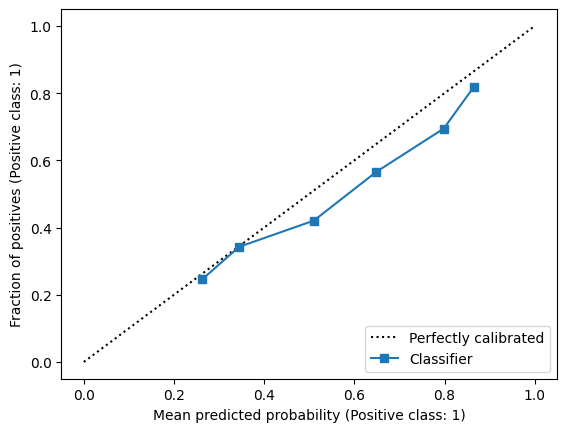

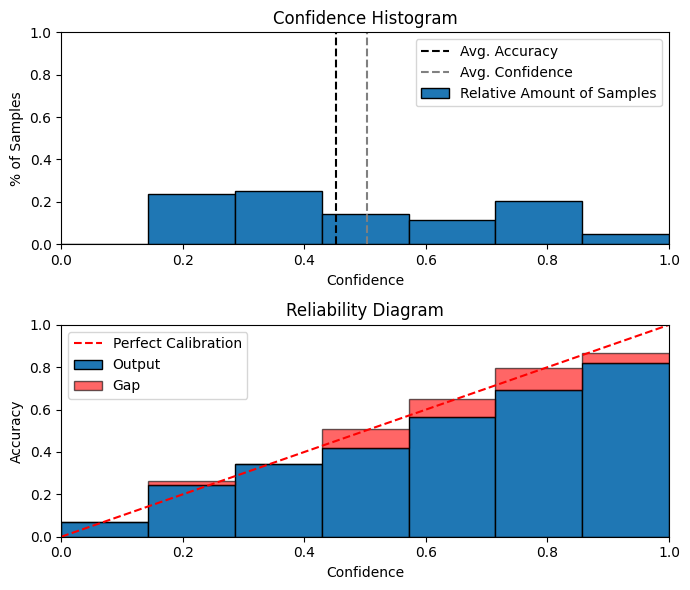

In [77]:
y_true = [label2id[x] for x in new_data['Actual_ID_Accuracy']]

from sklearn.calibration import CalibrationDisplay
from netcal.metrics import ACE
from netcal.presentation import ReliabilityDiagram

p1 = CalibrationDisplay.from_predictions(y_true, probs, n_bins = 7, strategy = 'uniform')

n_bins = 7
ece = np.round(ACE(bins = n_bins).measure(np.array(probs), np.array(y_true)), 3)

p2 = ReliabilityDiagram(n_bins).plot(np.array(probs), np.array(y_true))

In [78]:
print('AUC:', np.round(roc_auc_score(y_true, probs), 3))
print('Balanced Accuracy:', np.round(balanced_accuracy_score(y_true, preds), 3))
print('Macro F1:', np.round(f1_score(y_true, preds, average = 'macro'), 3))
print('ECE', ece)

AUC: 0.714
Balanced Accuracy: 0.668
Macro F1: 0.668
ECE 0.057


In [79]:
if False:
    p1.figure_.savefig('../results/calibration_' + model_name + '.png', bbox_inches = 'tight')
    p2.savefig('../results/reliability_' + model_name + '.png', bbox_inches = 'tight')
    new_data.to_excel('../results/results_' + model_name + '.xlsx', index = False)